# Find the optimal hyperparameters for the base Gaussian Mixture Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
output_path     = os.getenv('INFERENCE_READY_DATA_PATH')
posterior_path   = os.getenv('POSTERIOR_PATH')
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(output_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(output_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(output_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(output_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(output_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(output_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 833)
Shape of Ns_standardized_train: (256, 256, 1, 833)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


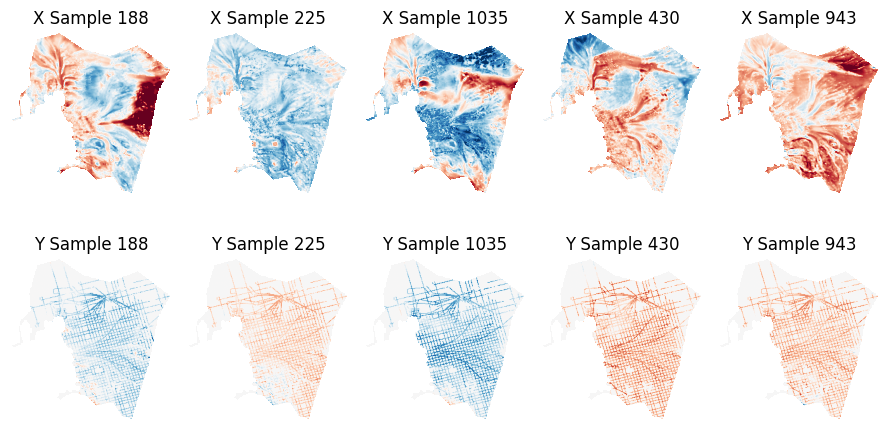

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

In [3]:
# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=50, n_component_y=15)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)


PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (833, 65)
Shape of XY_validation: (104, 65)
Shape of XY_test: (105, 65)


In [10]:
def score(x_true, gmm):
    """
    Compute the score of a Gaussian Mixture model, 
    by computing the log likelihood of the true data 
    with a conditioned Y
    
    score = log p(x_i | y_i)
    where x_i is the ground truth and y_i is the observed data
    here x_i is the latent basal enthalpy and y_i is the latent observed attenuation rate
    """
    from src.probability import to_log_probability_density
    score = to_log_probability_density(gmm, x_true)
    return score

n_gaussian = np.arange(1, 41, 2)
n_valid_samples = md.n_samples_validation

score_dict = {}


for n_optimal in n_gaussian:
    md.train_gmm_XY(n_components=n_optimal)

    score_values = np.zeros(n_valid_samples,)
    for i in range(n_valid_samples):
        y_valid = md.XY_validation[i, :md.ndim_reduced_y]  # Y part
        x_valid = md.XY_validation[i, md.ndim_reduced_y:]  # X part

        # Predict X given Y
        condition_index = np.arange(md.ndim_reduced_y)
        x_pred_gmm = md.gmm.condition(condition_index, y_valid)

        # get score
        try:
            score_values[i] = score(x_valid, x_pred_gmm)
        except Exception as e:
            print(f"Error computing score for sample {i}: {e}")
            score_values[i] = np.nan  # Assign NaN if there's an error

    # key pair as n_optimal: score_values / n_valid_samples
    score_dict[n_optimal] = score_values.mean() / n_valid_samples
    print(f"n_optimal: {n_optimal}, score: {score_dict[n_optimal]:.4f}")


GMM training completed in 0.03 seconds.
n_optimal: 1, score: -1.6354


/tmp/ipykernel_508925/2918296633.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_values[i] = score(x_valid, x_pred_gmm)


GMM training completed in 1.21 seconds.
n_optimal: 3, score: -1.5826
GMM training completed in 2.17 seconds.
n_optimal: 5, score: -1.6024
GMM training completed in 0.38 seconds.
n_optimal: 7, score: -2.1037
GMM training completed in 0.33 seconds.
n_optimal: 9, score: -2.2692
GMM training completed in 0.36 seconds.
n_optimal: 11, score: -9.7846
GMM training completed in 7.34 seconds.
n_optimal: 13, score: -11.0872
GMM training completed in 0.45 seconds.
n_optimal: 15, score: -6.6122
GMM training completed in 0.45 seconds.
n_optimal: 17, score: -8.4664
GMM training completed in 1.02 seconds.
n_optimal: 19, score: -7.4761
GMM training completed in 1.01 seconds.
n_optimal: 21, score: -46.6684
GMM training completed in 0.93 seconds.
n_optimal: 23, score: -10.5861
GMM training completed in 0.70 seconds.
n_optimal: 25, score: -35.4422
GMM training completed in 0.50 seconds.
n_optimal: 27, score: -17.0664
GMM training completed in 0.36 seconds.
n_optimal: 29, score: -244.8502
GMM training comp

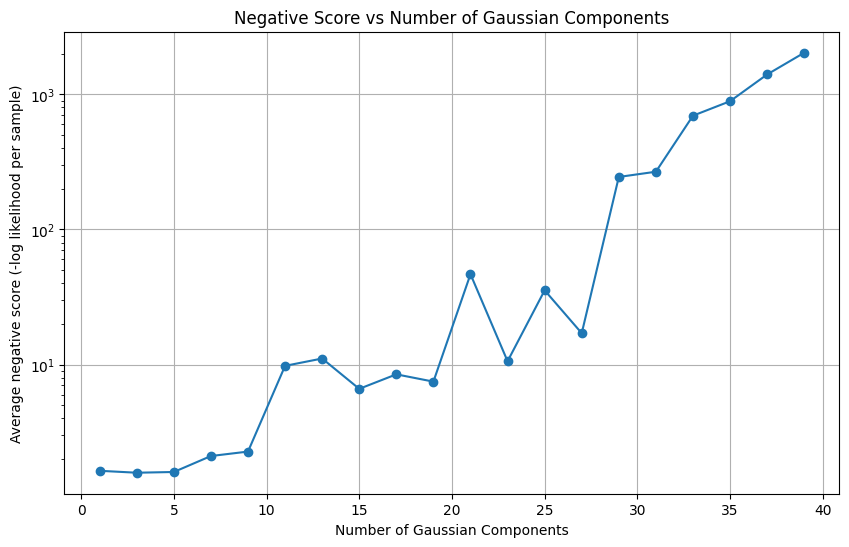

In [11]:
# plot the score vs n_optimal
plt.figure(figsize=(10, 6))
plt.semilogy(list(score_dict.keys()), -1 * np.array(list(score_dict.values())), marker='o')
plt.title('Negative Score vs Number of Gaussian Components')
plt.xlabel('Number of Gaussian Components')
plt.ylabel('Average negative score (-log likelihood per sample)')
plt.grid()
plt.savefig("../figs/negative_score_vs_n_gaussian.png", dpi=300)
plt.show()

A finer zoom in!

In [21]:
n_gaussian = np.arange(1, 20, 1)
n_valid_samples = md.n_samples_validation

score_dict = {}
for n_optimal in n_gaussian:
    md.train_gmm_XY(n_components=n_optimal)

    score_values = np.zeros(n_valid_samples,)
    for i in range(n_valid_samples):
        y_valid = md.XY_validation[i, :md.ndim_reduced_y]  # Y part
        x_valid = md.XY_validation[i, md.ndim_reduced_y:]  # X part

        # Predict X given Y
        condition_index = np.arange(md.ndim_reduced_y)
        x_pred_gmm = md.gmm.condition(condition_index, y_valid)

        # get score
        try:
            score_values[i] = score(x_valid, x_pred_gmm)
        except Exception as e:
            print(f"Error computing score for sample {i}: {e}")
            score_values[i] = np.nan  # Assign NaN if there's an error

    # key pair as n_optimal: score_values / n_valid_samples
    score_dict[n_optimal] = score_values.mean() / n_valid_samples
    print(f"n_optimal: {n_optimal}, score: {score_dict[n_optimal]:.4f}")



GMM training completed in 0.05 seconds.
n_optimal: 1, score: -1.6354


/tmp/ipykernel_508925/1369761872.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_values[i] = score(x_valid, x_pred_gmm)


GMM training completed in 1.77 seconds.
n_optimal: 2, score: -1.5824
GMM training completed in 1.11 seconds.
n_optimal: 3, score: -1.5341


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/probability.py:53: RuntimeWarning: divide by zero encountered in log
  log_prob_components[:, k] = np.log(gmm.priors[k]) + log_norm + log_exponent


GMM training completed in 2.00 seconds.
n_optimal: 4, score: -1.5455
GMM training completed in 2.21 seconds.
n_optimal: 5, score: -1.6701
GMM training completed in 1.92 seconds.
n_optimal: 6, score: -1.7090
GMM training completed in 0.98 seconds.
n_optimal: 7, score: -1.7925
GMM training completed in 1.93 seconds.
n_optimal: 8, score: -1.9885
GMM training completed in 3.50 seconds.
n_optimal: 9, score: -3.0706
GMM training completed in 1.13 seconds.
n_optimal: 10, score: -2.8480
GMM training completed in 0.32 seconds.
n_optimal: 11, score: -2.9642
GMM training completed in 0.34 seconds.
n_optimal: 12, score: -25.7297
GMM training completed in 1.29 seconds.
n_optimal: 13, score: -5.0804
GMM training completed in 0.41 seconds.
n_optimal: 14, score: -4.9891
GMM training completed in 1.71 seconds.
n_optimal: 15, score: -2.8733
GMM training completed in 0.42 seconds.
n_optimal: 16, score: -6.0415
GMM training completed in 1.15 seconds.
n_optimal: 17, score: -85.9393
GMM training completed i

#### Plot the output for validation set and the test set

GMM training completed in 1.77 seconds.


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/probability.py:53: RuntimeWarning: divide by zero encountered in log
  log_prob_components[:, k] = np.log(gmm.priors[k]) + log_norm + log_exponent
/tmp/ipykernel_508925/3532125077.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_values[i] = score(x_test, x_pred_gmm)


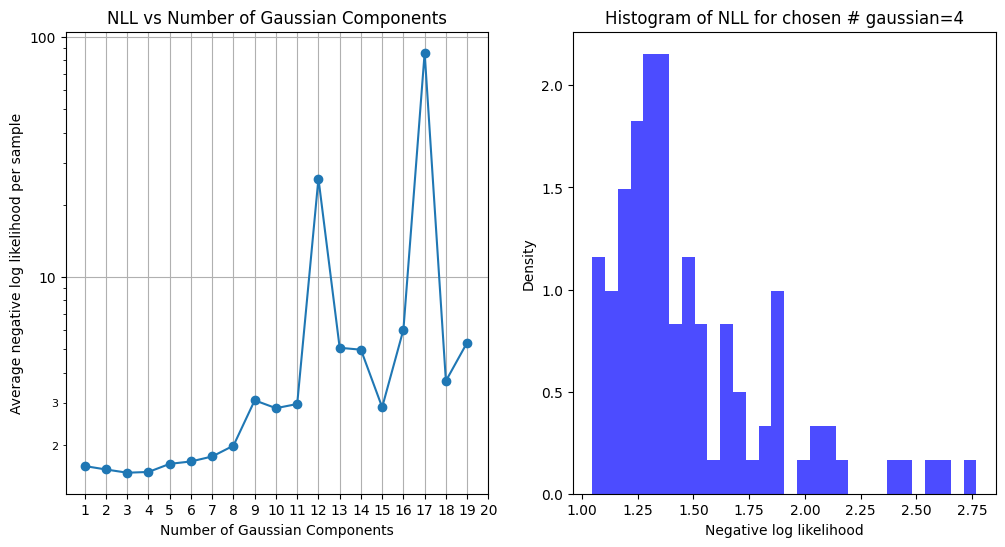

In [29]:
import matplotlib.ticker as ticker


n_gaussian = 4
n_test_samples = md.n_samples_test

md.train_gmm_XY(n_components=n_gaussian)

score_values = np.zeros(n_test_samples,)
for i in range(n_test_samples):
    y_test = md.XY_test[i, :md.ndim_reduced_y]  # Y part
    x_test = md.XY_test[i, md.ndim_reduced_y:]  # X part

    # Predict X given Y
    condition_index = np.arange(md.ndim_reduced_y)
    x_pred_gmm = md.gmm.condition(condition_index, y_test)

    # get score
    try:
        score_values[i] = score(x_test, x_pred_gmm)
    except Exception as e:
        print(f"Error computing score for sample {i}: {e}")
        score_values[i] = np.nan  # Assign NaN if there's an error

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.semilogy(list(score_dict.keys()), -1 * np.array(list(score_dict.values())), marker='o')
plt.title('NLL vs Number of Gaussian Components')
plt.xticks(np.arange(1, 21, 1))
plt.xlabel('Number of Gaussian Components')
plt.ylabel('Average negative log likelihood per sample')
plt.grid()

# --- Custom y-axis ticks ---
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=[1.0], numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=[2, 3, 4, 5, 6, 7, 8, 9], numticks=50))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}'))
ax.yaxis.set_minor_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}' if y in [2, 3] else ''))
ax.tick_params(axis='y', which='minor', labelsize=8)



plt.subplot(1, 2, 2)
plt.hist( -1 * score_values / n_test_samples, bins=30, density=True, alpha=0.7, color='blue')
plt.title(f'Histogram of NLL for chosen # gaussian={n_gaussian}')
plt.xlabel('Negative log likelihood')
plt.ylabel('Density')
plt.savefig("../figs/negative_score_histogram_n_gaussian_4.png", dpi=300)
plt.show()




GMM training completed in 2.13 seconds.


/tmp/ipykernel_508925/522207345.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_values[i] = score(x_test, x_pred_gmm)


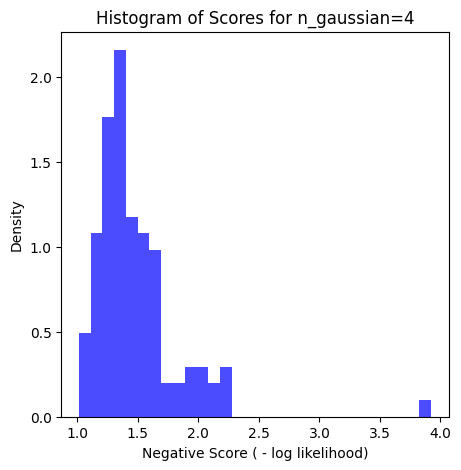